In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/ieee-fraud-detection/sample_submission.csv
/kaggle/input/competitions/ieee-fraud-detection/test_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/test_transaction.csv
/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv


In [3]:
%pip install -U dagshub mlflow skops --quiet

Note: you may need to restart the kernel to use updated packages.


In [4]:
import dagshub
dagshub.init(repo_owner='gvakh23', repo_name='ML_assignment2', mlflow=True)

Accessing as gvakh23

Initialized MLflow to track repo "gvakh23/ML_assignment2"

Repository gvakh23/ML_assignment2 initialized!

In [5]:
import mlflow
print(mlflow.get_tracking_uri())

https://dagshub.com/gvakh23/ML_assignment2.mlflow


In [6]:
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

train_trans  = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv')
train_ident  = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv')
test_trans   = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/test_transaction.csv')
test_ident   = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/test_identity.csv')


train = train_trans.merge(train_ident, on='TransactionID', how='left')
test  = test_trans.merge(test_ident,  on='TransactionID', how='left')

In [7]:

print(f"Train shape: {train.shape}")
print(f"Test  shape: {test.shape}")


Train shape: (590540, 434)
Test  shape: (506691, 433)


# EDA

## The "Imbalance" Problem
This is a classic imbalanced dataset. In such cases, accuracy is a misleading metric. If a model simply predicts "0" (Not Fraud) for every single transaction, it would achieve 96.5% accuracy while failing to catch even a single criminal.

### Impact on Strategy
**Metric Selection:** We cannot rely on Accuracy. We must use AUC-ROC (Area Under the Receiver Operating Characteristic curve) or Precision-Recall to evaluate our model's performance.

**Sampling Techniques:** We will need to use techniques like SMOTE (creating synthetic fraud cases) or Under-sampling (reducing legitimate cases) to help the model "see" the fraud patterns more clearly.

**Model Weights:** When training models like XGBoost or LightGBM, we should use parameters like scale_pos_weight to tell the model that the 3.5% of fraud cases are much more important than the rest.

In [8]:
print("=== TARGET DISTRIBUTION ===")
fraud_rate = train['isFraud'].value_counts(normalize=True)
print(fraud_rate)
print(f"\nFraud count: {train['isFraud'].sum():,}  /  {len(train):,} total")
print(f"Fraud rate:  {fraud_rate[1]:.2%}")

=== TARGET DISTRIBUTION ===
isFraud
0   0.97
1   0.03
Name: proportion, dtype: float64

Fraud count: 20,663  /  590,540 total
Fraud rate:  3.50%


## GROUPING
The IEEE dataset contains hundreds of features categorized by prefixes. We grouped them to better understand the data structure

In [9]:
print("\n=== DTYPE BREAKDOWN ===")
print(train.dtypes.value_counts())


print("\n=== COLUMN GROUPS ===")
groups = {
    'V features':    [c for c in train.columns if c.startswith('V')],
    'C features':    [c for c in train.columns if c.startswith('C')],
    'D features':    [c for c in train.columns if c.startswith('D')],
    'M features':    [c for c in train.columns if c.startswith('M')],
    'id features':   [c for c in train.columns if c.startswith('id')],
    'card features': [c for c in train.columns if c.startswith('card')],
}
for name, cols in groups.items():
    print(f"  {name}: {len(cols)} columns")


=== DTYPE BREAKDOWN ===
float64    399
object      31
int64        4
Name: count, dtype: int64

=== COLUMN GROUPS ===
  V features: 339 columns
  C features: 14 columns
  D features: 17 columns
  M features: 9 columns
  id features: 38 columns
  card features: 6 columns


In [10]:
# Create a list of all columns that ARE in a group
grouped_cols = []
for cols in groups.values():
    grouped_cols.extend(cols)

ungrouped_cols = [c for c in train.columns if c not in grouped_cols]

print(f"Ungrouped columns ({len(ungrouped_cols)}):")
print(ungrouped_cols)

Ungrouped columns (11):
['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain']


## MISSING VALUE ANALYSIS
nearly 50% of your columns (214 out of 434) are more than half empty

In [11]:
print("\n=== MISSING VALUE ANALYSIS===")
missing = train.isnull().mean().sort_values(ascending=False)
missing_df = missing[missing > 0].reset_index()
missing_df.columns = ['feature', 'missing_pct']
missing_df['missing_pct_str'] = missing_df['missing_pct'].map('{:.1%}'.format)

print(f"Columns with ANY missing: {len(missing_df)} / {train.shape[1]}")
print(f"\nMissing % buckets:")
for threshold in [0.99, 0.95, 0.9, 0.8, 0.7, 0.5, 0.3, 0.1]:
    count = (missing_df['missing_pct'] >= threshold).sum()
    print(f"  >= {threshold:.0%} missing: {count} columns")


=== MISSING VALUE ANALYSIS===
Columns with ANY missing: 414 / 434

Missing % buckets:
  >= 99% missing: 40 columns
  >= 95% missing: 40 columns
  >= 90% missing: 42 columns
  >= 80% missing: 95 columns
  >= 70% missing: 208 columns
  >= 50% missing: 214 columns
  >= 30% missing: 232 columns
  >= 10% missing: 322 columns


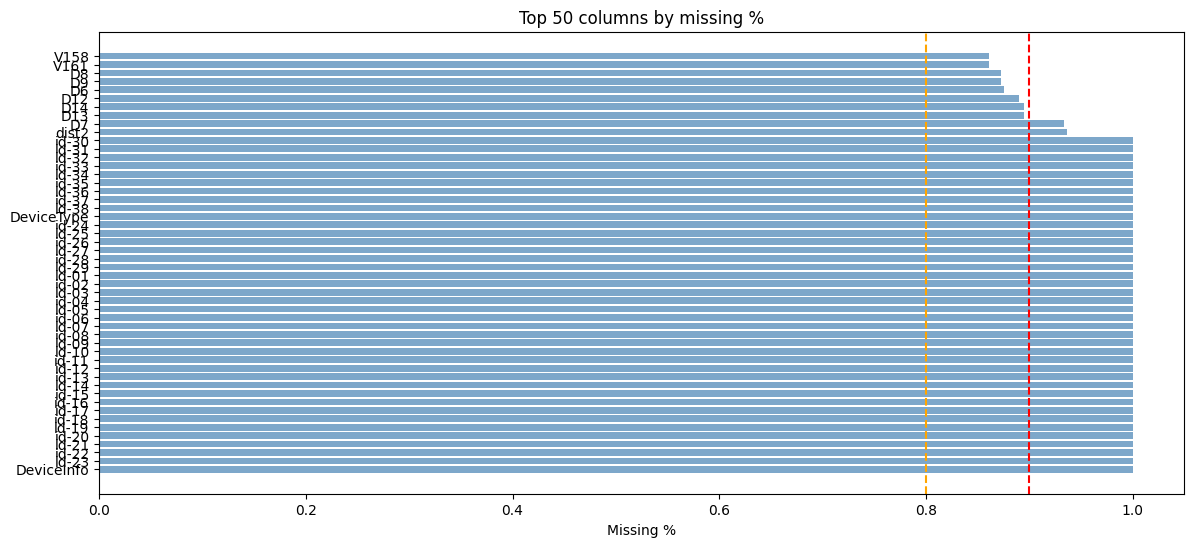

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 6))
top50 = missing_df.head(50)
bars = ax.barh(top50['feature'], top50['missing_pct'], color='steelblue', alpha=0.7)
ax.axvline(0.9, color='red',    linestyle='--', label='90% threshold')
ax.axvline(0.8, color='orange', linestyle='--', label='80% threshold')
ax.set_xlabel('Missing %')
ax.set_title('Top 50 columns by missing %')
plt.show()

In [13]:
print("\nMissing % by feature group:")
for name, cols in groups.items():
    if cols:
        avg_miss = train[cols].isnull().mean().mean()
        print(f"  {name}: {avg_miss:.1%} avg missing")


Missing % by feature group:
  V features: 43.0% avg missing
  C features: 0.0% avg missing
  D features: 63.1% avg missing
  M features: 49.9% avg missing
  id features: 100.0% avg missing
  card features: 0.5% avg missing


## TIME & TARGET
### 1. Temporal Trends (Fraud rate over time)
**Observation:** The fraud rate is volatile and does not remain constant, showing several significant spikes throughout the training period.

**Insight:** Fraud behavior is dynamic. We must treat time as a critical factor and consider features like day of the week or hour to capture these shifting patterns.

### 2. Transaction Value (log(TransactionAmt) distribution)
**Observation:** The distribution of fraudulent transactions (red) almost perfectly overlaps with legitimate transactions (blue) when viewed on a logarithmic scale.

**Insight:** The absolute dollar amount is not a standalone indicator of fraud. We will likely need "Aggregated Features" (e.g., comparing a current transaction to a user’s historical average) to find anomalies.

### 3. Data Split Strategy (Train vs Test time split)
**Observation:** There is a clear "time gap" between the Training set and the Test set. The Test data occurs entirely in the chronological future relative to the Training data.

**Insight:** Standard K-Fold Cross-Validation is unsuitable. To avoid data leakage and simulate the Kaggle leaderboard, we must use a Time-Series Split (training on earlier data and validating on the most recent "future" data).

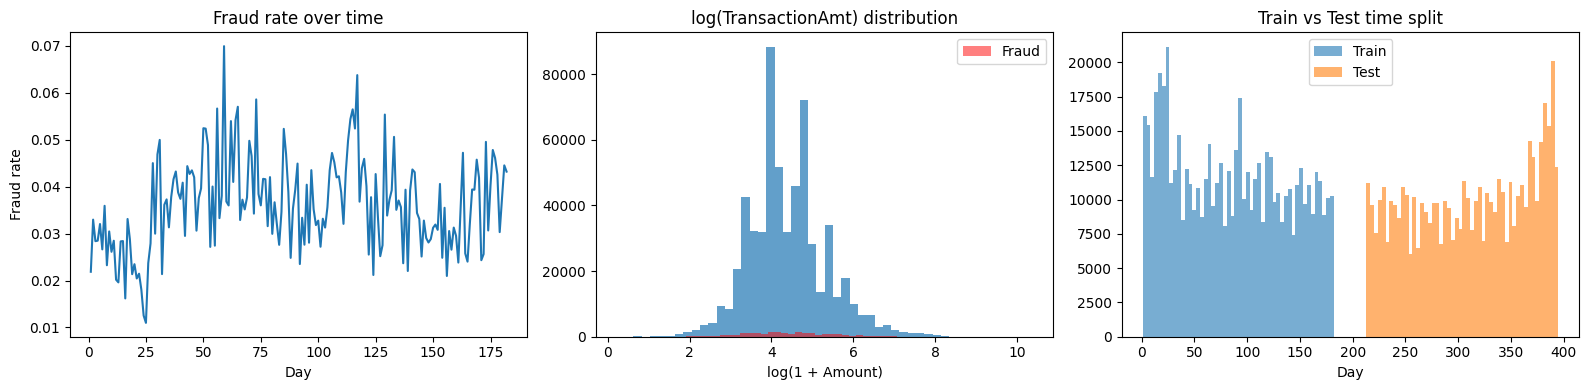

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Fraud rate over time
train['day'] = train['TransactionDT'] // (3600 * 24)
fraud_by_day = train.groupby('day')['isFraud'].mean()
axes[0].plot(fraud_by_day.index, fraud_by_day.values)
axes[0].set_title('Fraud rate over time')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Fraud rate')

# 2. Transaction amount distribution
axes[1].hist(np.log1p(train['TransactionAmt']), bins=50, edgecolor='none', alpha=0.7)
axes[1].hist(np.log1p(train[train['isFraud']==1]['TransactionAmt']), 
             bins=50, edgecolor='none', alpha=0.5, color='red', label='Fraud')
axes[1].set_title('log(TransactionAmt) distribution')
axes[1].set_xlabel('log(1 + Amount)')
axes[1].legend()

# 3. Train vs Test time overlap check
axes[2].hist(train['TransactionDT'] // (3600*24), bins=50, alpha=0.6, label='Train')
axes[2].hist(test['TransactionDT']  // (3600*24), bins=50, alpha=0.6, label='Test')
axes[2].set_title('Train vs Test time split')
axes[2].set_xlabel('Day')
axes[2].legend()

plt.tight_layout()
plt.show()


In [15]:
print(train.columns)

Index(['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt',
       'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5',
       ...
       'id-32', 'id-33', 'id-34', 'id-35', 'id-36', 'id-37', 'id-38',
       'DeviceType', 'DeviceInfo', 'day'],
      dtype='object', length=435)


In [16]:
print(train['TransactionDT'])

0            86400
1            86401
2            86469
3            86499
4            86506
            ...   
590535    15811047
590536    15811049
590537    15811079
590538    15811088
590539    15811131
Name: TransactionDT, Length: 590540, dtype: int64


## CATEGORICAL ANALYSIS
This analysis identifies the risk profile of non-numeric features by calculating the mean fraud rate for their most suspicious categories. We visualize the top 10 highest-risk values for each feature to pinpoint "fraud magnets," such as specific anonymous email domains or product codes. Simultaneously, we calculate the cardinality (unique value count) for each column, which is essential for deciding our encoding strategy: low-cardinality features (like ProductCD) can use One-Hot Encoding, while high-cardinality features (like P_emaildomain) will require Label or Target Encoding to prevent the dataset from becoming too sparse.

Categorical columns: ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id-12', 'id-15', 'id-16', 'id-23', 'id-27', 'id-28', 'id-29', 'id-30', 'id-31', 'id-33', 'id-34', 'id-35', 'id-36', 'id-37', 'id-38', 'DeviceType', 'DeviceInfo']



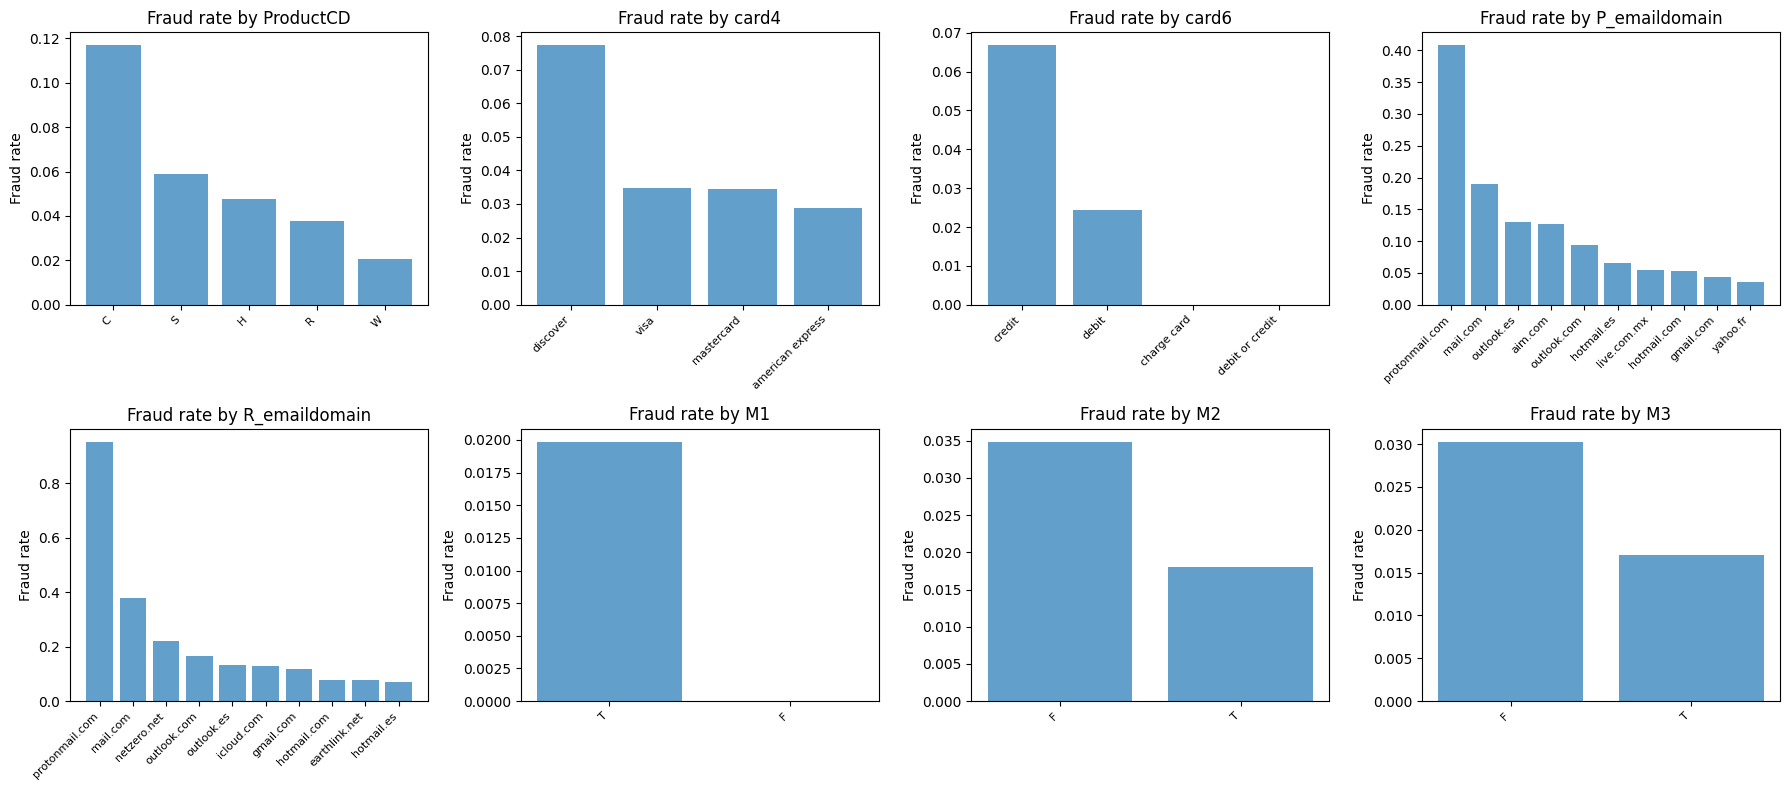

Cardinality (unique values per categorical column):
  ProductCD: 5 unique values
  card4: 4 unique values
  card6: 4 unique values
  P_emaildomain: 59 unique values
  R_emaildomain: 60 unique values
  M1: 2 unique values
  M2: 2 unique values
  M3: 2 unique values
  M4: 3 unique values
  M5: 2 unique values
  M6: 2 unique values
  M7: 2 unique values
  M8: 2 unique values
  M9: 2 unique values
  id-12: 0 unique values
  id-15: 0 unique values
  id-16: 0 unique values
  id-23: 0 unique values
  id-27: 0 unique values
  id-28: 0 unique values
  id-29: 0 unique values
  id-30: 0 unique values
  id-31: 0 unique values
  id-33: 0 unique values
  id-34: 0 unique values
  id-35: 0 unique values
  id-36: 0 unique values
  id-37: 0 unique values
  id-38: 0 unique values
  DeviceType: 0 unique values
  DeviceInfo: 0 unique values


In [17]:
cat_cols = train.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns: {cat_cols}\n")

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols[:8]):
    fraud_rate_by_cat = train.groupby(col)['isFraud'].mean().sort_values(ascending=False)
    top10 = fraud_rate_by_cat.head(10)
    axes[i].bar(range(len(top10)), top10.values, alpha=0.7)
    axes[i].set_xticks(range(len(top10)))
    axes[i].set_xticklabels(top10.index, rotation=45, ha='right', fontsize=8)
    axes[i].set_title(f'Fraud rate by {col}')
    axes[i].set_ylabel('Fraud rate')

plt.tight_layout()
plt.show()

# Cardinality of each categorical
print("Cardinality (unique values per categorical column):")
for col in cat_cols:
    n_unique = train[col].nunique()
    print(f"  {col}: {n_unique} unique values")

In [18]:
print(train['id-35'].unique())

[nan]


## V COLUMNS NaN PATTERN ANALYSIS
We analyzed the 339 V-features and discovered that they collapse into only 15 distinct missing-value patterns, confirming that these features were recorded in synchronized "blocks." Within the largest block (Group 0), we found high internal correlation, suggesting that many of these columns are redundant duplicates of the same underlying signal. This analysis allows us to drastically reduce the dimensionality of the dataset by selecting only one or two representative "lead" features from each of the 15 groups.

In [19]:
# Group V cols by their NaN pattern — key for feature selection
v_cols = [c for c in train.columns if c.startswith('V')]
v_null = train[v_cols].isnull()

# Each V col gets a null-pattern "group ID"
null_patterns = {}
for col in v_cols:
    pattern = tuple(v_null[col].values)
    if pattern not in null_patterns:
        null_patterns[pattern] = []
    null_patterns[pattern].append(col)

print(f"V columns: {len(v_cols)}")
print(f"Distinct NaN patterns: {len(null_patterns)}")
print("\nGroup sizes:")
for i, (pat, cols) in enumerate(sorted(null_patterns.items(), key=lambda x: -len(x[1]))):
    null_rate = sum(pat) / len(pat)
    print(f"  Group {i}: {len(cols)} cols, {null_rate:.1%} null — {cols[:5]}...")

# Correlation within V cols (to identify redundancy)
print("\nChecking correlation within first V group...")
first_group = list(null_patterns.values())[0][:10]
if len(first_group) > 1:
    corr = train[first_group].corr().abs()
    high_corr = (corr > 0.90).sum().sum() - len(first_group)
    print(f"  Pairs with >0.90 correlation in this group: {high_corr}")

V columns: 339
Distinct NaN patterns: 15

Group sizes:
  Group 0: 46 cols, 77.9% null — ['V217', 'V218', 'V219', 'V223', 'V224']...
  Group 1: 43 cols, 0.1% null — ['V95', 'V96', 'V97', 'V98', 'V99']...
  Group 2: 32 cols, 0.0% null — ['V279', 'V280', 'V284', 'V285', 'V286']...
  Group 3: 31 cols, 76.4% null — ['V167', 'V168', 'V172', 'V173', 'V176']...
  Group 4: 23 cols, 12.9% null — ['V12', 'V13', 'V14', 'V15', 'V16']...
  Group 5: 22 cols, 13.1% null — ['V53', 'V54', 'V55', 'V56', 'V57']...
  Group 6: 20 cols, 15.1% null — ['V75', 'V76', 'V77', 'V78', 'V79']...
  Group 7: 19 cols, 76.3% null — ['V169', 'V170', 'V171', 'V174', 'V175']...
  Group 8: 18 cols, 28.6% null — ['V35', 'V36', 'V37', 'V38', 'V39']...
  Group 9: 18 cols, 86.1% null — ['V138', 'V139', 'V140', 'V141', 'V142']...
  Group 10: 18 cols, 86.1% null — ['V322', 'V323', 'V324', 'V325', 'V326']...
  Group 11: 16 cols, 76.1% null — ['V220', 'V221', 'V222', 'V227', 'V234']...
  Group 12: 11 cols, 47.3% null — ['V1', 'V2',

##  IMBALANCE & CARD FEATURES
The dataset exhibits a severe class imbalance, requiring a scale_pos_weight of 27.6 to ensure the XGBoost model prioritizes the rare fraud cases. Analysis of the card features reveals that card1 is a high-cardinality "anchor" ID with significant overlap between Train and Test sets, making it a primary candidate for grouping and identity-based feature engineering. The low cardinality of card4 (brand) and card6 (type) suggests these should be treated as categorical categories to capture broad risk profiles across different payment methods.

In [20]:
# Class balance
neg = (train['isFraud'] == 0).sum()
pos = (train['isFraud'] == 1).sum()
print(f"scale_pos_weight for XGBoost = {neg/pos:.1f}")
print(f"(set this as a hyperparameter to handle imbalance)\n")

# Card feature analysis
card_cols = ['card1','card2','card3','card4','card5','card6']
print("Card column analysis:")
for col in card_cols:
    print(f"  {col}: {train[col].nunique()} unique, "
          f"{train[col].isnull().mean():.1%} null, "
          f"dtype={train[col].dtype}")


scale_pos_weight for XGBoost = 27.6
(set this as a hyperparameter to handle imbalance)

Card column analysis:
  card1: 13553 unique, 0.0% null, dtype=int64
  card2: 500 unique, 1.5% null, dtype=float64
  card3: 114 unique, 0.3% null, dtype=float64
  card4: 4 unique, 0.3% null, dtype=object
  card5: 119 unique, 0.7% null, dtype=float64
  card6: 4 unique, 0.3% null, dtype=object
  card1 overlap train↔test: 9,706 values
  card2 overlap train↔test: 496 values


##  D COLUMNS (time-delta features)
The D columns function as cumulative time-deltas (days since a specific event), which naturally causes "data drift" as values in the Test set are chronologically higher than the Train set. By applying the Deotte Normalization—subtracting the minimum D1 value within each card1 group—we shift the feature from a global timeline to a user-specific lifecycle. This transformation preserves the information (unique count remains 641) while creating a stationary feature that allows the model to recognize "new user" behavior consistently across both datasets.

In [21]:
d_cols = [c for c in train.columns if c.startswith('D')]
print("D column stats (these are time deltas):")
print(train[d_cols].describe().T[['count','mean','std','min','max']].to_string())

# D1 normalization preview
train['D1_norm'] = train['D1'] - train.groupby('card1')['D1'].transform('min')
print(f"\nD1 raw    — unique values: {train['D1'].nunique():,}")
print(f"D1 normed — unique values: {train['D1_norm'].nunique():,}")
print("(normalized D1 is more stable across clients → better feature)")

D column stats (these are time deltas):
        count   mean    std     min     max
D1  589271.00  94.35 157.66    0.00  640.00
D2  309743.00 169.56 177.32    0.00  640.00
D3  327662.00  28.34  62.38    0.00  819.00
D4  421618.00 140.00 191.10 -122.00  869.00
D5  280699.00  42.34  89.00    0.00  819.00
D6   73187.00  69.81 143.67  -83.00  873.00
D7   38917.00  41.64  99.74    0.00  843.00
D8   74926.00 146.06 231.66    0.00 1707.79
D9   74926.00   0.56   0.32    0.00    0.96
D10 514518.00 123.98 182.62    0.00  876.00
D11 311253.00 146.62 186.04  -53.00  670.00
D12  64717.00  54.04 124.27  -83.00  648.00
D13  61952.00  17.90  67.61    0.00  847.00
D14  62187.00  57.72 136.31 -193.00  878.00
D15 501427.00 163.74 202.73  -83.00  879.00

D1 raw    — unique values: 641
D1 normed — unique values: 641
(normalized D1 is more stable across clients → better feature)


In [22]:
summary = {
    'Total features':      train.shape[1],
    'Rows (train)':        train.shape[0],
    'Fraud rate':          f"{train['isFraud'].mean():.2%}",
    'scale_pos_weight':    f"{neg/pos:.0f}",
    'Cols >90% missing':   (train.isnull().mean() > 0.9).sum(),
    'Cols >80% missing':   (train.isnull().mean() > 0.8).sum(),
    'Categorical cols':    len(cat_cols),
    'V column NaN groups': len(null_patterns),
    'D columns':           len(d_cols),
}
print("=== EDA SUMMARY — USE THIS TO PLAN CLEANING ===")
for k, v in summary.items():
    print(f"  {k:30s}: {v}")

=== EDA SUMMARY — USE THIS TO PLAN CLEANING ===
  Total features                : 436
  Rows (train)                  : 590540
  Fraud rate                    : 3.50%
  scale_pos_weight              : 28
  Cols >90% missing             : 42
  Cols >80% missing             : 95
  Categorical cols              : 31
  V column NaN groups           : 15
  D columns                     : 17
